
# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

# Solution to Exercice 1: 



In [ ]:
# librerias:

import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt 
from scipy import interpolate
import scipy.integrate as integrate


In [84]:
# Definimos la fuente y la solución exacta que satisface nuestra ecuación diferencial:

def x_expo(x):
    return (x) * np.exp(x) 

def Sol1(x):
    return (2 - x)*np.exp(x) - x + (1 - np.e)


# Puntos a graficar
N = 50; h = 1/(N-1)
u = np.zeros(N , float);
b = np.zeros(N, float );

#steps: elements, malla
xi = np.zeros(N ,float );
for i in range(0,N):
    xi[i] = i*h


# A matrix (integrated analytical)
A = np.zeros((N, N), float );
for i in range( 1 , N):
    A[i-1,i-1] = A[i-1,i-1] + 1/ h
    A[i-1,i] = A[i-1,i] - 1/h
    A[i,i-1] = A[i-1,i]
    A[i,i]= A[i,i] + 1/ h

#Initial conditions
A[0,:] = 0; A[0,0] = 1
A[N-1,:] = 0; A[N-1,N-1] = 1
b[0] = 3 - np.e
b[N-1] = 0


In [83]:
#phi(x) functions
def lin1(x, x1, x2):
    return (x-x1)/(x2-x1)

def lin2(x, x1, x2):
    return (x2-x)/(x2-x1)

In [85]:

#Integrales para elementos Bi usando quad:

def int1(min, max):
    return integrate.quad(lambda x: lin1(x, min, max) * x_expo(x), min, max)[0]

def int2(min, max):
    return integrate.quad(lambda x: lin2(x, min, max) * x_expo(x), min, max)[0]



# Matriz B de integración:

b = np.zeros(N, float);

for i in range(1 , N):
    b[i-1] = b[i-1] + int2( xi[i-1], xi[i] )
    b[i] = b[i] + int1( xi[i-1], xi[i] )


#Initial conditions
b[0] = (3-np.e)
b[N-1] = 0

# Solución 1: using Gaussian elimination in numpy
sol = np.linalg.solve(A, b)


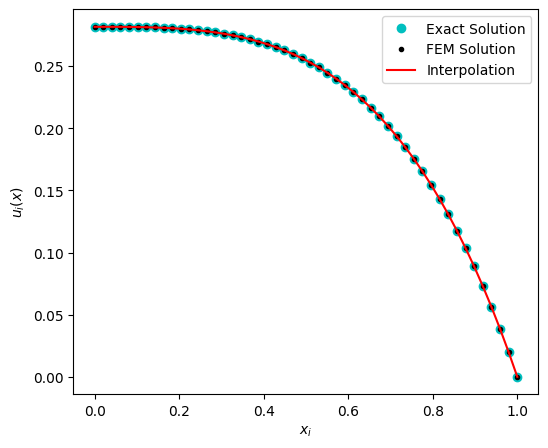

In [86]:
# Puntos a graficar:

x_new = np.linspace(0,1)
y_new = np.interp(x_new, xi, sol)

# Gráfica:
plt.figure(figsize=(6, 5))
plt.plot(xi, Sol1(xi),'co', label='Exact Solution')
plt.plot(xi, sol,'k.', label='FEM Solution')
plt.plot(x_new, y_new,'r-', label='Interpolation')
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.show()

### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

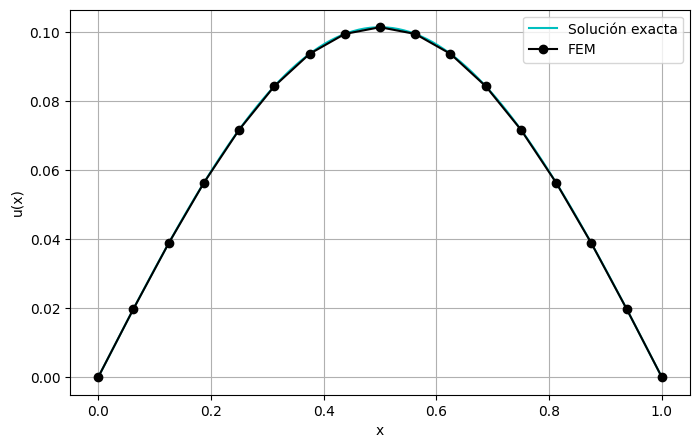

In [88]:
# Número de elementos
n = 16
hk = 1/n
nodes = np.linspace(0, 1, n+1)

# Inicialización
A = np.zeros((n-1, n-1))
b = np.zeros(n-1)

# Funciones de forma lineales
def N1(x, x1, x2):
    return (x2 - x)/(x2 - x1)

def N2(x, x1, x2):
    return (x - x1)/(x2 - x1)

# Fuente
def f(x):
    return np.sin(np.pi * x)

# Ensamblaje
for k in range(1, n+1):
    xk1 = (k-1)*hk
    xk  = k*hk

    # Matriz elemental
    Ak = (1/hk) * np.array([[1, -1],
                            [-1, 1]])

    # Vector de cargas elemental (integración numérica)
    bk = np.zeros(2)
    bk[0] = integrate.quad(lambda x: N1(x, xk1, xk)*f(x), xk1, xk)[0]
    bk[1] = integrate.quad(lambda x: N2(x, xk1, xk)*f(x), xk1, xk)[0]

    # Ensamblaje global
    if k == 1:
        A[0,0] += Ak[1,1]
        b[0]   += bk[1]
    elif k == n:
        A[n-2,n-2] += Ak[0,0]
        b[n-2]     += bk[0]
    else:
        A[k-2,k-2] += Ak[0,0]; A[k-2,k-1] += Ak[0,1]
        A[k-1,k-2] += Ak[1,0]; A[k-1,k-1] += Ak[1,1]
        b[k-2]     += bk[0];   b[k-1]     += bk[1]

# Resolver sistema
u = np.linalg.solve(A, b)

# Solución exacta
x_vals = np.linspace(0, 1, 200)
u_exact = (1/np.pi**2)*np.sin(np.pi*x_vals)

# Interpolación FEM (añadimos extremos con u=0)
u_fem = np.zeros(n+1)
u_fem[1:-1] = u

# Plot
plt.figure(figsize=(8,5))
plt.plot(x_vals, u_exact, 'c-', label='Solución exacta')
plt.plot(nodes, u_fem, 'ko-', label='FEM')
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True)
plt.show()
